<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 10: *Fire Damage*
##### Version Number: 4.0
---
### Contents  
> *Build Models*\
> *Train Models*\
> *Generate Predictions*\
> *Geospatial Visualization*\
> *Export File*
---
### Notes
This section applies the trained models to predict wildfire severity in real-world scenarios.

It evaluates and compare the performance of three classification models:
- **XGBoost**
- **Random Forest**
- **LightGBM**
---
### Inputs
- `X_damage`,`y_damage` ,`details_damage` - Model testing dataset in full or reduced versions 
- `pal_X`,`pal_y`, `pal_details` Case study data for 2025 predictions
- `damage_best_strategy` best class balancing strategies calculated from module 06
- `damage_model_parameters` optimum model parameters as determined by module 07

---
### Outputs  
- `damage_predictions.csv` Dataset containing prediction models composed of a categorical prediction 0,1,2 to be used for interpolation in ArcGIS. 
- **Date range** 01/01/2025 to 01/23/2025.
---
### User Created Dependencies  

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import json
# Modeling libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point

---
### Global Constants

In [3]:
# first day to analyze in weather dataset
FIRST_DATE = pd.to_datetime('2018-01-01').date()

# last day to analyze in weather dataset
LAST_DATE = pd.to_datetime('2024-12-31').date()

---

### Load Data

In [4]:
X_damage = pd.read_csv('../data/processed/X_damage.csv')
y_damage = pd.read_csv('../data/processed/y_damage.csv').squeeze()  
details_damage = pd.read_csv('../data/processed/details_damage.csv')

pal_details = pd.read_csv('../data/processed/pal_details.csv')
pal_X = pd.read_csv('../data/processed/pal_X.csv')
pal_y = pd.read_csv('../data/processed/pal_y.csv')

best_strategy = pd.read_csv('../data/processed/damage_best_strategy.csv')

with open('../data/processed/model_parameters_damage.json', 'r') as f:
    model_parameters = json.load(f)

In [5]:
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date
details_damage['Date'] = pd.to_datetime(details_damage['Date']).dt.date

In [6]:
best_strategy

,Model_Label,Best_Strategy
0,Damage XGB,No_balance
1,Damage RF,No_balance


## Build Models

In [7]:
RF_parameters = model_parameters['Random Forest']
XGB_parameters = model_parameters['XGBoost']

# Build tuned models
damage_xgb = xgb.XGBClassifier(**XGB_parameters)
damage_rf = RandomForestClassifier(**RF_parameters)

display(RF_parameters)
display(XGB_parameters)

{'n_estimators': 150,
 'max_depth': 20,
 'min_samples_split': 5,
 'max_features': 'sqrt',
 'class_weight': 'balanced'}

{'objective': 'multi:softmax',
 'num_class': 5,
 'n_estimators': 200,
 'max_depth': 6,
 'learning_rate': 0.3,
 'verbosity': 0}

## Train Models

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_damage, y_damage, test_size=0.2, random_state=14)

In [9]:
X_train_rf, y_train_rf = apply_balancing('RF', best_strategy, X_train, y_train)
X_train_xgb, y_train_xgb = apply_balancing('XGB', best_strategy, X_train, y_train)

damage_rf.fit(X_train_rf, y_train_rf)
damage_xgb.fit(X_train_xgb, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=5,
              num_parallel_tree=None, ...)

## Metrics

In [10]:
evaluate_model(damage_xgb, X_test, y_test, "Damage XGBoost")
evaluate_model(damage_rf, X_test, y_test, "Damage Random Forest")

Evaluation for Damage XGBoost
Accuracy:  0.994
Precision: 0.994
Recall:    0.994
F1 Score:  0.994


---- Classification Report ----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7986
           1       0.98      0.99      0.98       355
           2       0.97      0.98      0.98       345
           3       0.97      0.98      0.97       350
           4       0.97      0.98      0.97       342

    accuracy                           0.99      9378
   macro avg       0.98      0.99      0.98      9378
weighted avg       0.99      0.99      0.99      9378



Evaluation for Damage Random Forest
Accuracy:  0.992
Precision: 0.992
Recall:    0.992
F1 Score:  0.992


---- Classification Report ----
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      7986
           1       0.96      0.99      0.98       355
           2       0.97      0.98      0.97       345
           3       0.9

In [11]:
# Create a Series for easy sorting
damage_rf_importances = pd.Series(damage_rf.feature_importances_, index=X_damage.columns)
damage_xgb_importances = pd.Series(damage_xgb.feature_importances_, index=X_damage.columns)

# Get top 10
damage_rf_top10 = damage_rf_importances.sort_values(ascending=False).head(10)
damage_xgb_top10 = damage_xgb_importances.sort_values(ascending=False).head(10)

rf_top10 = pd.DataFrame({
    'Random Forest': damage_rf_top10
})

xgb_top10 = pd.DataFrame({
    'XGBoost': damage_xgb_top10
})

display(rf_top10,xgb_top10)

,Random Forest
avg_dist_to_all_reservoirs_same_day,0.032491
Palmer Drought Severity Index,0.028727
influence_zone,0.022754
fire_count 30 Day Sum,0.021374
intermix_zone,0.018700
Vapor Pressure Deficit 30 Day Mean,0.018378
avg_dist_to_past_fires,0.018017
log_total_reservoir_level,0.017460
Daily Maximum Air Temperature 30 Day Mean,0.017270
1000-hour Dead Fuel Moisture 30 Day Median,0.016569


,XGBoost
road_density_x_forest_percent,0.109858
road_length_meters,0.046630
fire_count 30 Day Sum,0.029236
dominant_province_description_Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow,0.028082
influence_zone,0.024605
log_housing_density,0.023231
Vapor Pressure Deficit 30 Day Mean,0.022200
intermix_zone,0.020995
dominant_province_description_American Semi-Desert and Desert,0.020871
Season_Summer,0.019864


## Generate Case Study Predictions

In [12]:
pal_damage_xgb_predictions = pd.DataFrame(damage_xgb.predict(pal_X))
pal_damage_xgb_predictions.value_counts()

0
0    5170
3      22
Name: count, dtype: int64

In [13]:
pal_damage_rf_predictions = pd.DataFrame(damage_rf.predict(pal_X))
pal_damage_rf_predictions.value_counts()

0
0    5177
3      14
2       1
Name: count, dtype: int64

### Save Predictions for plotting

In [14]:
pal_details = pal_details.copy()

pal_details['Prediction Damage XGB'] = pal_damage_xgb_predictions[0].values
pal_details['Prediction Damage RF']  = pal_damage_rf_predictions[0].values
pal_details['Prediction Damage Actual'] = pal_y['Target_Damage']

#### Identify specific day to plot

In [15]:
pal_specific_date = pd.to_datetime('2025-01-07').date()
pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

#### Define geometries

In [16]:
pal_details['geometry'] = [Point(xy) for xy in zip(pal_details['centroid_easting'], pal_details['centroid_northing'])]
pal_gdf = gpd.GeoDataFrame(pal_details , geometry='geometry', crs="EPSG:3310")

pal_gdf = pal_gdf.to_crs('4326')

pal_gdf['Longitude'] = pal_gdf.geometry.x
pal_gdf['Latitude'] = pal_gdf.geometry.y

#### Subset data for visualization

In [17]:
pal_predictions = pal_gdf[pal_gdf['Date'] == pal_specific_date]

## Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025).

### Fire Damage Risk Predictions
- Date: 01/07/2025

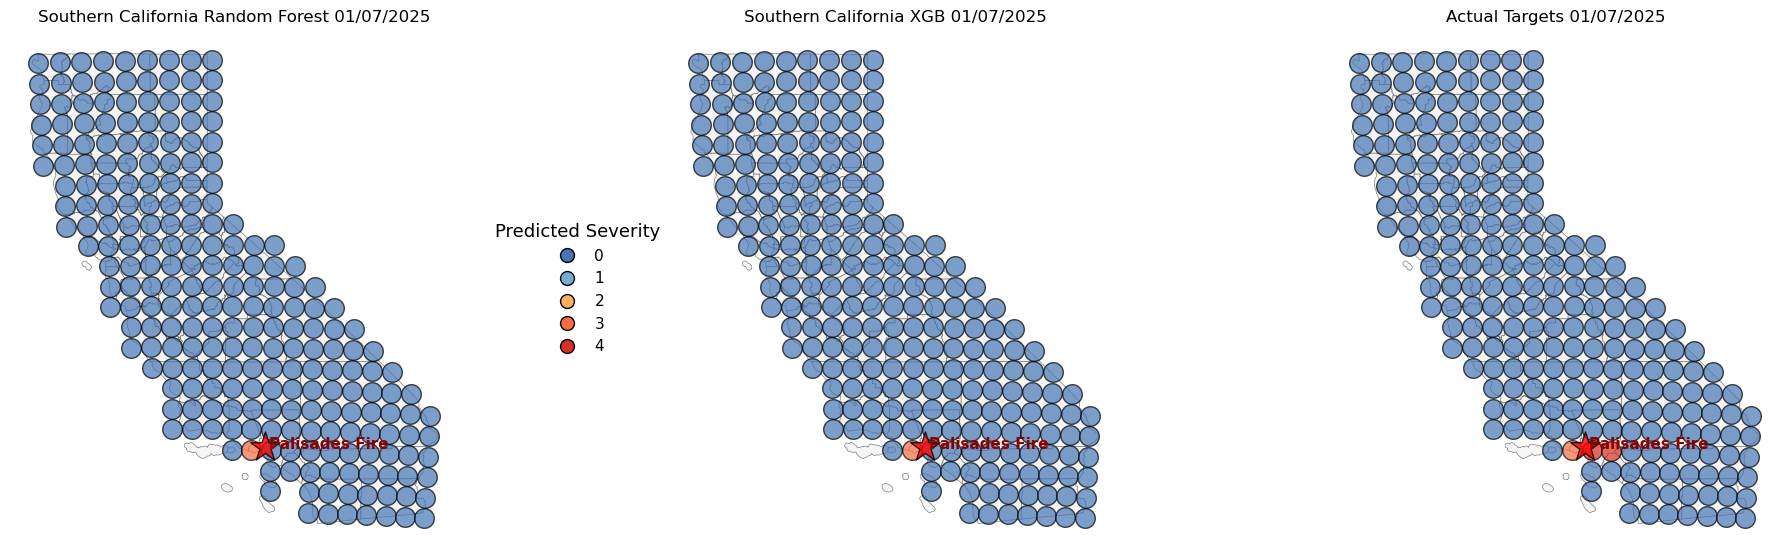

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_predictions, 'Prediction Damage RF', 'Palisades', ax=axes[0])
plot_map(pal_predictions, 'Prediction Damage XGB', 'Palisades', ax=axes[1])
plot_map(pal_predictions, 'Prediction Damage Actual', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California XGB 01/07/2025')
axes[2].set_title('Actual Targets 01/07/2025')

plt.tight_layout()

## 3. Export File

In [19]:
pal_gdf.to_csv('../data/processed/predictions_damage.csv', index=False)
print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/
